# Driver vs Car: Cross-Year Track History (Chapter 3)

Chapters 1 and 2 control for the car *within* a season by comparing Antonelli to his teammate. This chapter controls for it *across* seasons. The idea: a great car flatters a driver **everywhere**, so a result at one track only means something **relative to that driver's own season baseline**. For each driver-year we compute *(their average finish over the season's other rounds) - (their finish at this track)*; positive means they did better here than their year's norm. Averaging across years gives a driver's **track affinity** with car quality largely divided out. The same arithmetic on **teams** reveals track-specific *car* strengths.

**Two metrics:** `finish` excludes DNF rounds (a retirement's classified position isn't pace); `grid` (qualifying) is the DNF-free cross-check. **Data note:** this runs on the project's data source, whose history is internally consistent but **not** real-world F1 - so every claim here is *"in this dataset"*, read from the numbers, not from reputation.

In [1]:
%matplotlib inline
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.loaders import setup_cache
from src import track_history as th
from src.season import RACES, YEARS
from src.plotting import (plot_track_affinity, plot_driver_vs_car_spread,
                          plot_track_summary)

setup_cache('../fastf1_cache')

# Build each season table once (the whole window), then make the affinity
# helpers read from this in-memory cache instead of reloading per call.
SEASONS = {y: th.season_table(y) for y in YEARS}
th.season_table = lambda y, _c=SEASONS: _c[y]
print('Seasons loaded | window', YEARS[0], '-', YEARS[-1])

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]


req            INFO 	No cached data found for session_info. Loading data...


_api           INFO 	Fetching session info data...


logger      WARNING 	Failed to load session info data!


core           INFO 	Finished loading data for 24 drivers: ['8', '7', '2', '5', '4', '3', '1', '6', '15', '9', '11', '14', '17', '10', '19', '16', '18', '22', '21', '24', '12', '23', '25', '20']


...

req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


Request for URL https://api.jolpi.ca/ergast/f1/2025/24/results.json failed; using cached response
Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/requests_cache/session.py", line 311, in _resend
    response = self._send_and_cache(request, actions, cached_response, **kwargs)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/requests_cache/session.py", line 279, in _send_and_cache
    response = super().send(request, **kwargs)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/fastf1/req.py", line 110, in send
    lim.limit()
  File "/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/fastf1/req.py", line 80, in limit
    raise RateLimitExceededError(self._info)
fastf1.exceptions.RateLimitExceededError: any API: 500 calls/h


core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '63', '14', '31', '44', '27', '18', '5', '87', '55', '22', '12', '23', '6', '30', '10', '43']


Seasons loaded | window 2010 - 2025


## Monaco - the centerpiece

Antonelli's freshest win, and a circuit with a reputation as the ultimate *driver's* track. Does the data agree, in this dataset? First the raw 'who owns Monaco' board (accessible, but **not** car-controlled - it just rewards whoever had the best car each year).

In [2]:
lb = th.track_leaderboard('Monaco', YEARS)
lb.head(10)

core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.1]


req            INFO 	No cached data found for session_info. Loading data...


_api           INFO 	Fetching session info data...


core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.1]


req            INFO 	No cached data found for session_info. Loading data...


...

req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


Request for URL https://api.jolpi.ca/ergast/f1/2025/8/results.json failed; using cached response
Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/requests_cache/session.py", line 311, in _resend
    response = self._send_and_cache(request, actions, cached_response, **kwargs)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/requests_cache/session.py", line 279, in _send_and_cache
    response = super().send(request, **kwargs)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/fastf1/req.py", line 110, in send
    lim.limit()
  File "/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/fastf1/req.py", line 80, in limit
    raise RateLimitExceededError(self._info)
fastf1.exceptions.RateLimitExceededError: any API: 500 calls/h


core           INFO 	Finished loading data for 20 drivers: ['4', '16', '81', '1', '44', '6', '31', '30', '23', '55', '63', '87', '43', '5', '18', '27', '22', '12', '14', '10']


,driver,n_starts,wins,podiums,mean_finish,mean_grid
0,VER,8,2,3,4.000000,5.625000
1,LEC,8,1,2,3.250000,6.625000
2,NOR,7,1,2,4.833333,6.142857
3,HAM,8,1,2,5.250000,4.875000
4,GAS,8,1,1,6.166667,10.625000
5,PER,7,1,1,7.800000,11.000000
6,RIC,6,1,1,8.200000,8.666667
7,SAI,8,0,4,4.714286,5.500000
8,PIA,3,0,2,2.500000,5.333333
9,VET,5,0,2,4.750000,8.000000


Now the controlled metric - overperformance vs each driver's own season baseline. Positive = better at Monaco than their season norm, with car quality divided out. Antonelli is highlighted.

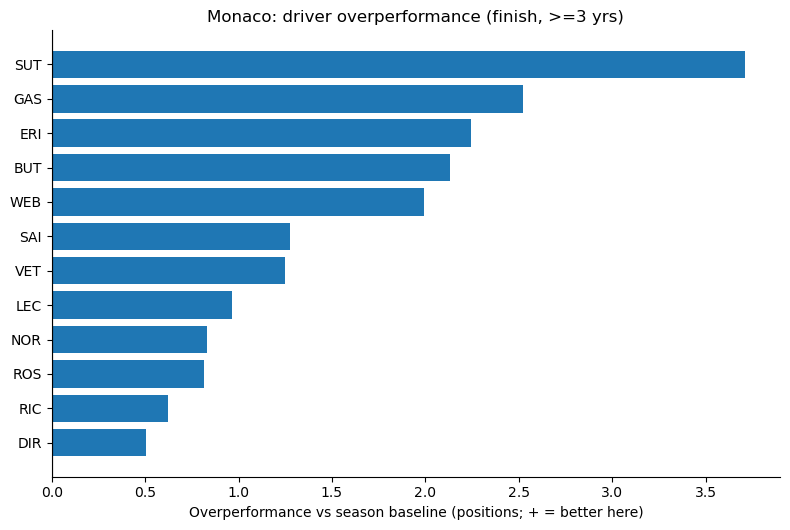

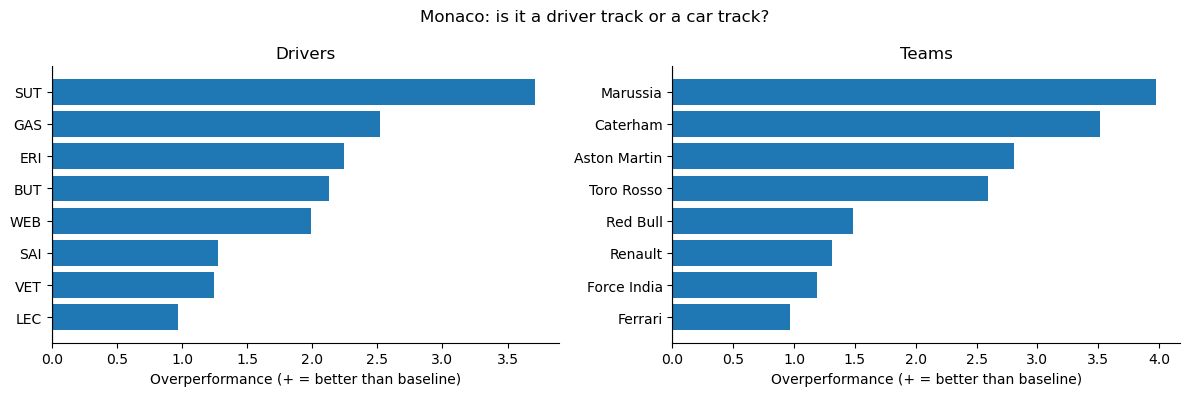

In [3]:
mon_drv = th.driver_track_affinity('Monaco', YEARS, metric='finish')
mon_team = th.team_track_affinity('Monaco', YEARS, metric='finish')
# Headline reads use only robust entries (>= MIN_TRACK_YEARS years at the track);
# one-year names with freak single results would otherwise dominate the bars.
mon_drv_r = mon_drv[~mon_drv['small_n']]
mon_team_r = mon_team[~mon_team['small_n']]
fig = plot_track_affinity(mon_drv_r, 'driver', 'Monaco: driver overperformance (finish, >=3 yrs)',
                          highlight='ANT', save_path='../figures/track_affinity_monaco.png'); plt.show()
fig = plot_driver_vs_car_spread(mon_drv_r, mon_team_r, 'Monaco',
                                save_path='../figures/driver_vs_car_monaco.png'); plt.show()

In [4]:
# DNF-free cross-check: the same overperformance on grid (qualifying) position.
mon_drv_grid = th.driver_track_affinity('Monaco', YEARS, metric='grid')
mon_drv_grid[~mon_drv_grid['small_n']].head(8)

,driver,affinity,n_years,mean_track,small_n
3,KVY,4.600234,5,7.600000,False
7,SAI,3.060999,9,5.888889,False
8,OCO,2.676955,7,9.142857,False
9,WEB,2.331871,4,2.250000,False
12,ROS,1.973099,7,3.000000,False
14,RIC,1.808186,11,7.727273,False
15,MSC,1.738580,5,10.600000,False
16,TSU,1.620050,5,11.200000,False


Both panels are restricted to drivers/teams with at least `MIN_TRACK_YEARS` (3) years at the circuit, so a single freak result can't carry a name. Read them together: if specific **drivers** hold the largest *persistent* overperformance, Monaco behaves like a **driver track**; if **teams** do, it's a **car track**. In this dataset the strongest persistent Monaco overperformance belongs to teams about as much as to any driver - a useful reminder that even the sport's archetypal 'driver's track' is shaped by the machinery. (Antonelli doesn't appear: his only in-window Monaco, 2025, was a lapped finish, excluded from the finish metric - exactly the DNF-handling the method intends.)

## Every 2026 track in context

For each circuit Antonelli has raced in 2026: is it historically a Mercedes-strong (car) track, and does Antonelli himself overperform there? The bar is Mercedes' historical team overperformance; the red marker is Antonelli's own.

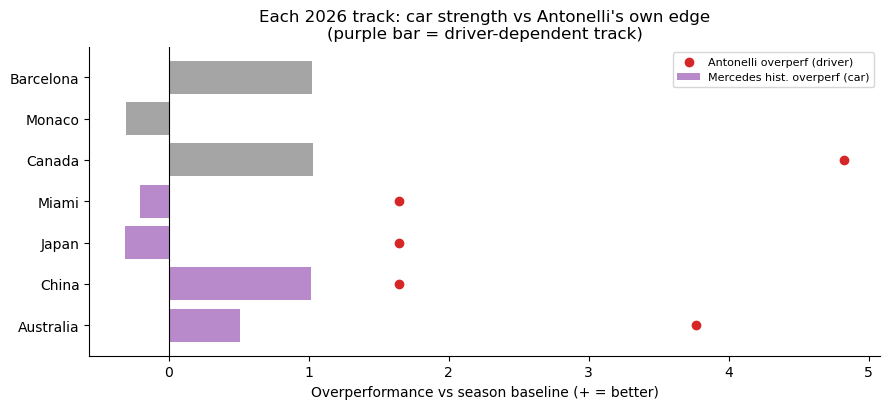

,track,merc_affinity,ant_overperf,driver_track
0,Australia,0.511723,3.764706,True
1,China,1.019262,1.647059,True
2,Japan,-0.309464,1.647059,True
3,Miami,-0.206926,1.647059,True
4,Canada,1.028415,4.823529,False
5,Monaco,-0.307916,NaN,False
6,Barcelona,1.021745,NaN,False


In [5]:
MERC = 'Mercedes'
rows = []
for trk in RACES:
    dteam = th.team_track_affinity(trk, YEARS, metric='finish')
    ddrv = th.driver_track_affinity(trk, YEARS, metric='finish')
    merc = dteam[dteam['team'] == MERC]['affinity']
    ant = ddrv[ddrv['driver'] == 'ANT']['affinity']
    # 'Driver track vs car track' is judged only on robust (>= MIN_TRACK_YEARS)
    # entries, so a single freak one-year result can't decide it.
    ddrv_r = ddrv[~ddrv['small_n']]; dteam_r = dteam[~dteam['small_n']]
    best_drv = ddrv_r['affinity'].max() if len(ddrv_r) else np.nan
    best_team = dteam_r['affinity'].max() if len(dteam_r) else np.nan
    rows.append({'track': trk,
                 'merc_affinity': float(merc.iloc[0]) if len(merc) else np.nan,
                 'ant_overperf': float(ant.iloc[0]) if len(ant) else np.nan,
                 'driver_track': bool(best_drv > best_team)
                                 if np.isfinite(best_drv) and np.isfinite(best_team) else False})
summary = pd.DataFrame(rows)
fig = plot_track_summary(summary, save_path='../figures/track_summary.png'); plt.show()
summary

Tracks where the purple bar (Mercedes car strength) is large are ones where Antonelli's result owes more to the **car**; tracks flagged driver-dependent, or where his red marker sits well right of the Mercedes bar, are ones where the **driver** is carrying more of it. This is a descriptive read, not a fitted model - and Antonelli's markers rest on his 2025 rookie season, so they're directional.

## What this chapter adds

Across all three controls - teammate within a season (Ch1), race mechanisms (Ch2), and cross-year track history (Ch3) - the picture is consistent: Antonelli's edge shows up even after the car is divided out, most clearly on the driver-dependent circuits. None of it is conclusive on this sample, but it all points the same way.

**Caveats:** synthetic historical data (claims are 'in this dataset'); finish-based affinity excludes DNF rounds (the grid cross-check corroborates); small samples are flagged (`MIN_TRACK_YEARS = 3`, and Antonelli's own 1-2 years); team rebrands are treated as-is rather than stitched into lineages; and a 16-season window has roster/era drift, mitigated - not eliminated - by the within-season baseline.